In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def preparar_red_optimizacion(nombres_nodos, grado_total, centralidad_c, centralidad_b):
    """
    Construye la estructura de la red y extrae el vector de pesos (x) 
    dependiendo de si los nodos son iones o no.
    """
    # 1. Identificación lógica de iones
    # Recorre la lista 'nombre_nodos' y devuelve True si contiene '+' o '-', y False si no.
    es_ion = [('+' in nodo or '-' in nodo) for nodo in nombres_nodos]
    
     # 2. Construimos el DataFrame estructurado
    df_nodos = pd.DataFrame({
        'nodo': nombres_nodos,
        'grado_total': grado_total,
        'centralidad_c': centralidad_c,
        'centralidad_b': centralidad_b,
        'ion' : es_ion
    })
    
    
    
    # 3. Devolvemos ambas cosas: la tabla visual
    return df_nodos


def mostrar_rankings_topologicos(df_nodos):
    """
    Toma el DataFrame de nodos y devuelve una tabla resumen con los 
    nodos ordenados de mayor a menor para cada métrica topológica.
    """
    # 1. Ordenamos de forma independiente por cada métrica (de mayor a menor)
    df_grado = df_nodos.sort_values(by='grado_total', ascending=False).reset_index(drop=True)
    df_close = df_nodos.sort_values(by='centralidad_c', ascending=False).reset_index(drop=True)
    df_betw  = df_nodos.sort_values(by='centralidad_b', ascending=False).reset_index(drop=True)
    
    # 2. Construimos un nuevo DataFrame para ver todo en paralelo
    df_resumen = pd.DataFrame({
        'Top_Grado': df_grado['nodo'],
        'Valor_Grado': df_grado['grado_total'],
        '|': '|', # Columna separadora visual
        'Top_Closeness': df_close['nodo'],
        'Valor_Close': df_close['centralidad_c'],
        '||': '|', # Columna separadora visual
        'Top_Betweenness': df_betw['nodo'],
        'Valor_Betw': df_betw['centralidad_b']
    })
    
    # 3. Ajustamos el índice para que empiece en 1 (como un ranking real)
    df_resumen.index = range(1, len(df_resumen) + 1)
    df_resumen.index.name = 'Ranking'
    
    return df_resumen

def calcular_peso_nodos(df_nodos, w1=0.4, w2=0.3, w3=0.3):
    """
    Calcula el Índice de Importancia (Peso) de cada nodo combinando sus métricas.
    Normaliza el grado total para que todas las variables estén entre 0 y 1.
    
    Parámetros:
    - df_nodos: El DataFrame devuelto por preparar_red_optimizacion()
    - w1: Peso dado al Grado Total
    - w2: Peso dado a la Centralidad de Intermediación (Betweenness)
    - w3: Peso dado a la Centralidad de Cercanía (Closeness)
    """
    # 1. Hacemos una copia para no alterar los datos originales por accidente
    df_eval = df_nodos.copy()
    
    # 2. Normalización del grado total (Escalado Min-Max de 0 a 1)
    max_grado = df_eval['grado_total'].max()
    min_grado = df_eval['grado_total'].min()
    
    # Evitamos dividir por cero en caso de que todos los nodos tengan el mismo grado
    if max_grado == min_grado:
        df_eval['grado_norm'] = 0.0
    else:
        df_eval['grado_norm'] = (df_eval['grado_total'] - min_grado) / (max_grado - min_grado)
        
    # 3. Función Matemática de Peso
    # Puntuación final = w1*Grado_Norm + w2*Betweenness + w3*Closeness
    df_eval['peso_optimizacion'] = (w1 * df_eval['grado_norm'] + 
                                    w2 * df_eval['centralidad_b'] + 
                                    w3 * df_eval['centralidad_c'])
    
    # 4. Crear el Ranking final ordenado por el peso (de menor a mayor o mayor a menor)
    # Como queremos saber qué eliminar, ordenamos de MAYOR a MENOR importancia
    df_ranking = df_eval.sort_values(by='peso_optimizacion', ascending=False).reset_index(drop=True)
    
    # Ajustamos el índice para que sea un ranking visual (1, 2, 3...)
    df_ranking.index = range(1, len(df_ranking) + 1)
    df_ranking.index.name = 'Rank'
    
    # Nos quedamos solo con las columnas más útiles para la vista final
    columnas_vista = ['nodo', 'peso_optimizacion', 'ion', 'grado_total', 'centralidad_b', 'centralidad_c']
    df_ranking_vista = df_ranking[columnas_vista]
    
    return df_eval, df_ranking_vista

import re

import re

def comentar_peores_nodos(df_ranking, ruta_chem, ruta_setup, metrica):
    """
    Busca los nodos con la peor puntuación según la métrica indicada,
    protegiendo siempre a los iones y electrones para conservar la cuasineutralidad,
    y comenta sus reacciones en el .chem y sus líneas en el .in.
    """
    
    # 1. Filtramos el DataFrame para aislar a los "borrables"
    # Protegemos si la columna 'ion' es True, o si el nombre del nodo es 'e'
    mascara_protegidos = df_ranking['ion'] | (df_ranking['nodo'] == 'e')
    df_borrables = df_ranking[~mascara_protegidos] # El símbolo ~ invierte la máscara (nos quedamos con los False)
    
    # Si por algún casual ya solo quedaran iones y electrones en la red, paramos
    if df_borrables.empty:
        print("⚠️ Alerta: Ya solo quedan iones y electrones en el plasma. Reducción detenida.")
        return []
    
    # 2. Identificamos el valor más bajo SOLO entre las especies neutrales borrables
    min_valor = df_borrables[metrica].min()
    nodos_condenados = df_borrables[df_borrables[metrica] == min_valor]['nodo'].tolist()
    
    print(f"🎯 Nodos neutrales para purgar (Métrica {metrica} = {min_valor}): {nodos_condenados}")
    
    # 3. Preparamos el "Buscador Láser" (Regex) 
    patrones = [re.compile(r'(?<![A-Za-z0-9_])' + re.escape(n) + r'(?![A-Za-z0-9_])') for n in nodos_condenados]
    
    # ==========================================
    # A. MODIFICAR EL ARCHIVO .CHEM
    # ==========================================
    try:
        with open(ruta_chem, 'r') as f_chem:
            lineas_chem = f_chem.readlines()
            
        lineas_chem_mod = []
        saltar = 0 
        
        for linea in lineas_chem:
            if saltar > 0:
                if not linea.strip().startswith('%'):
                    lineas_chem_mod.append('% ' + linea)
                else:
                    lineas_chem_mod.append(linea)
                saltar -= 1
                continue
                
            es_reaccion = ('->' in linea or '<->' in linea) and not linea.strip().startswith('%')
            
            if es_reaccion and any(p.search(linea) for p in patrones):
                lineas_chem_mod.append('% ' + linea) 
                saltar = 2 
            else:
                lineas_chem_mod.append(linea) 
                
        with open(ruta_chem, 'w') as f_chem:
            f_chem.writelines(lineas_chem_mod)
            
    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo {ruta_chem}")

    # ==========================================
    # B. MODIFICAR EL ARCHIVO SETUP .IN
    # ==========================================
    try:
        with open(ruta_setup, 'r') as f_setup:
            lineas_setup = f_setup.readlines()
            
        lineas_setup_mod = []
        for linea in lineas_setup:
            if not linea.strip().startswith('%') and any(p.search(linea) for p in patrones):
                lineas_setup_mod.append('% ' + linea)
            else:
                lineas_setup_mod.append(linea)
                
        with open(ruta_setup, 'w') as f_setup:
            f_setup.writelines(lineas_setup_mod)
            
    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo {ruta_setup}")
        
    return nodos_condenados

def leer_densidades_loki(ruta_resultados):
    """
    Abre el archivo chemFinalDensities.txt de LoKI, salta las cabeceras,
    y devuelve un diccionario con {nombre_especie: densidad_absoluta}.
    """
    densidades = {}
    try:
        with open(ruta_resultados, 'r') as f:
            for linea in f:
                linea = linea.strip()
                # Saltamos líneas vacías, cabeceras de texto o líneas divisorias
                if not linea or linea.startswith('*') or linea.startswith('-') or linea.startswith('Species'):
                    continue
                # Saltamos las líneas de los grupos principales (ej: He[99.999%])
                if '[' in linea and '%' in linea:
                    continue
                
                # Dividimos la línea por espacios
                partes = linea.split()
                if len(partes) >= 2:
                    especie = partes[0]
                    try:
                        # La densidad absoluta es la segunda columna
                        densidad = float(partes[1])
                        densidades[especie] = densidad
                    except ValueError:
                        continue # Si no es un número, pasamos
    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo de resultados en {ruta_resultados}")
        
    return densidades

In [ ]:
import subprocess
import shutil 
import os
import numpy as np
import sys 

# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def cambiar_carpeta_salida_loki(ruta_setup, nuevo_nombre):
    """
    Lee el archivo setup.in, busca la línea que define el output folder
    y la sustituye respetando los dos puntos (:) requeridos por el parser de LoKI.
    """
    try:
        with open(ruta_setup, 'r', encoding='utf-8') as f:
            lineas = f.readlines()
            
        for i, linea in enumerate(lineas):
            if 'folder' in linea.lower():
                espacios_iniciales = len(linea) - len(linea.lstrip())
                indentacion = linea[:espacios_iniciales]
                # Inyectamos el formato legal: folder: nombre
                lineas[i] = f"{indentacion}folder: {nuevo_nombre}\n"
                break 
                
        with open(ruta_setup, 'w', encoding='utf-8') as f:
            f.writelines(lineas)
    except Exception as e:
        print(f"🔴 Error al modificar la carpeta de salida en setup.in: {e}")
        sys.exit(1)

# =============================================================================
# BLOQUE PRINCIPAL: MOTOR DE ITERACIÓN
# =============================================================================

# 1. Configuración de Rutas
ruta_chem = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Input\Helium\helium.chem'
ruta_setup = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Input\Helium\helium_chem_setup.in'

ruta_default_chem = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\Helio\helium.chem'
ruta_default_setup = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\Helio\helium_chem_setup.in'
ruta_codigo_loki = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code'

comando_loki = "loki('Helium/helium_chem_setup.in')"
comando_consola = f'matlab -batch "cd(\'{ruta_codigo_loki}\'); {comando_loki}"'

# 2. Carga de datos topológicos 
nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_nodos_base = preparar_red_optimizacion(nombres_nodos, grado_total, centralidad_c, centralidad_b)
total_nodos_original = len(df_nodos_base)

# 3. ITERACIÓN 0: BASELINE
print("\n🚀 INICIANDO ITERACIÓN 0: Restaurando archivos y calculando plasma original...")
shutil.copy(ruta_default_chem, ruta_chem)
shutil.copy(ruta_default_setup, ruta_setup)

cambiar_carpeta_salida_loki(ruta_setup, "helium0")
resultado_base = subprocess.run(comando_consola, shell=True, capture_output=True, text=True)

if resultado_base.returncode == 0:
    print("🟢 Simulación original completada. LoKI ha creado la carpeta 'helium0'.")
else:
    print("\n🔴 FATAL ERROR: MATLAB ha fallado en la Iteración 0.")
    print(f"STDOUT:\n{resultado_base.stdout.strip()}")
    print(f"STDERR:\n{resultado_base.stderr.strip()}")
    sys.exit(1)

# 4. BUCLE DE OPTIMIZACIÓN
metricas_a_probar = ['grado_total', 'centralidad_b', 'centralidad_c']
nodos_minimos_objetivo = 20  

for metrica in metricas_a_probar:
    print(f"\n{'#'*60}\n🔥 INICIANDO OPTIMIZACIÓN BASADA EN: {metrica.upper()}\n{'#'*60}")
    
    shutil.copy(ruta_default_chem, ruta_chem)
    shutil.copy(ruta_default_setup, ruta_setup)
    df_nodos = df_nodos_base.copy()
    iteracion = 1
    
    while len(df_nodos) > nodos_minimos_objetivo:
        print(f"\n--- ITERACIÓN {iteracion} ({metrica}) ---")
        
        # Purga
        eliminados = comentar_peores_nodos(df_nodos, ruta_chem, ruta_setup, metrica)
        df_nodos = df_nodos[~df_nodos['nodo'].isin(eliminados)].reset_index(drop=True)
        print(f"Nodos vivos restantes: {len(df_nodos)}")
        
        # Nomenclatura nueva
        nombre_carpeta_iter = f"helium_{metrica}{iteracion}"
        cambiar_carpeta_salida_loki(ruta_setup, nombre_carpeta_iter)
        
        print("⏳ Ejecutando LoKI... (Esperando a MATLAB)")
        resultado = subprocess.run(comando_consola, shell=True, capture_output=True, text=True)
        
        if resultado.returncode == 0:
            print(f"🟢 Plasma estable. Resultados en: '{nombre_carpeta_iter}'.")
        else:
            print(f"\n🔴 ERROR CRÍTICO al eliminar {eliminados}. La matriz es singular.")
            break 
            
        iteracion += 1

print("\n🎉 SIMULACIONES TERMINADAS. Puedes pasar al SCRIPT 2.")


🚀 INICIANDO ITERACIÓN 0: Restaurando archivos y calculando plasma original...
🟢 Simulación original completada. LoKI ha creado la carpeta 'helium0'.

############################################################
🔥 INICIANDO OPTIMIZACIÓN BASADA EN: GRADO_TOTAL
############################################################

--- ITERACIÓN 1 (grado_total) ---
🎯 Nodos neutrales para purgar (Métrica grado_total = 20.0): ['He2(exc)']
Nodos vivos restantes: 46
⏳ Ejecutando LoKI... (Esperando a MATLAB)
🟢 Plasma estable. Resultados en: 'helium_grado_total1'.

--- ITERACIÓN 2 (grado_total) ---
🎯 Nodos neutrales para purgar (Métrica grado_total = 51.0): ['He(3S3)', 'He(3S1)']
Nodos vivos restantes: 44
⏳ Ejecutando LoKI... (Esperando a MATLAB)
🟢 Plasma estable. Resultados en: 'helium_grado_total2'.

--- ITERACIÓN 3 (grado_total) ---
🎯 Nodos neutrales para purgar (Métrica grado_total = 58.0): ['He(7S1)']
Nodos vivos restantes: 43
⏳ Ejecutando LoKI... (Esperando a MATLAB)
🟢 Plasma estable. Resultados e

⚙️ Analizando topología para seleccionar los VIPs (con Gas de Fondo)...


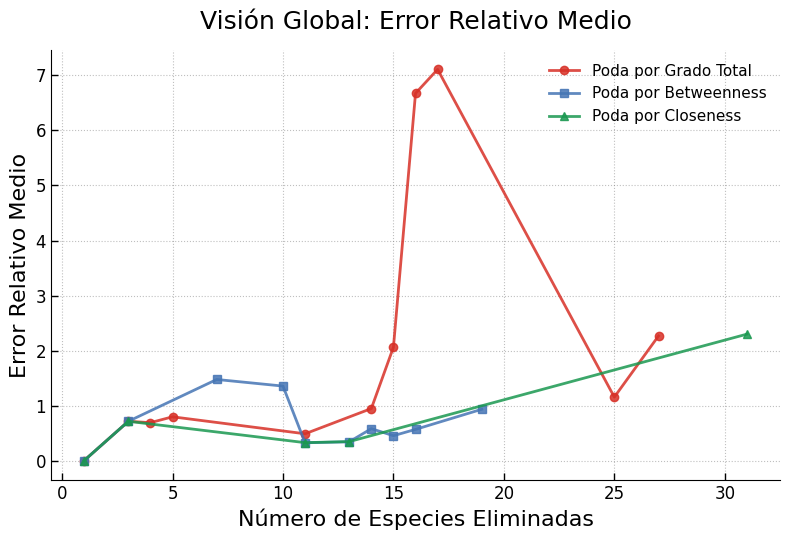

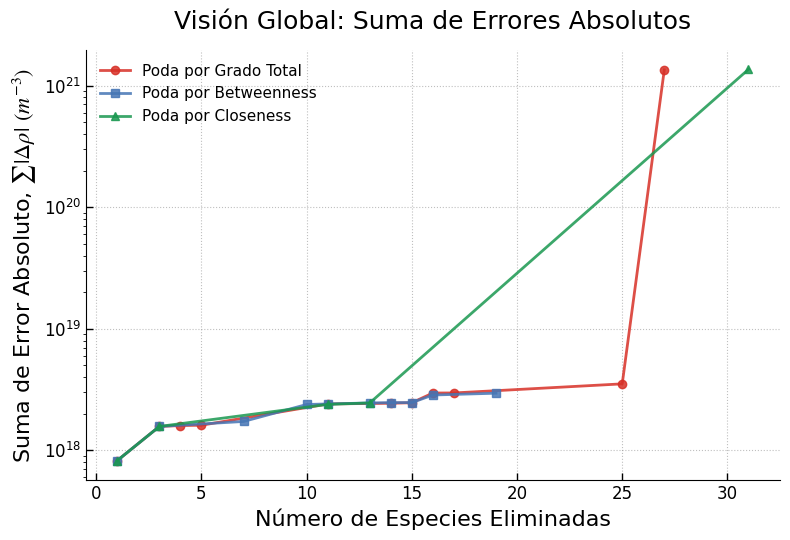

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================
# ⚠️ [PEGA AQUÍ TU FUNCIÓN: leer_densidades_loki()] ⚠️

# =============================================================================
# 1. CARGA DE TOPOLOGÍA Y SELECCIÓN DEL TOP 5 VIPS (INCLUYENDO He(1S1))
# =============================================================================
print("⚙️ Analizando topología para seleccionar los VIPs (con Gas de Fondo)...")

nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_topo = pd.DataFrame({'nodo': nombres_nodos, 'grado': grado_total, 'betw': centralidad_b, 'close': centralidad_c})
df_topo['es_ion'] = df_topo['nodo'].apply(lambda x: '+' in x or '-' in x)

def normalizar(columna):
    min_val, max_val = columna.min(), columna.max()
    if max_val == min_val: return columna * 0.0
    return (columna - min_val) / (max_val - min_val)

df_topo['peso_combinado'] = normalizar(df_topo['grado']) + normalizar(df_topo['betw']) + normalizar(df_topo['close'])

# Grupo VIP (AHORA INCLUYE AL He(1S1))
obligatorios = ['e', 'He(1S1)']
mejor_ion = df_topo[df_topo['es_ion'] & (df_topo['nodo'] != 'e')].sort_values(by='peso_combinado', ascending=False).iloc[0]['nodo']
obligatorios.append(mejor_ion)

# Seleccionamos los 2 restantes sin excluir nada
df_resto = df_topo[~df_topo['nodo'].isin(obligatorios)].sort_values(by='peso_combinado', ascending=False)
top_5_vips = obligatorios + df_resto['nodo'].tolist()[:2]

# =============================================================================
# 2. LECTURA DE ARCHIVOS DE SALIDA DE LOKI
# =============================================================================
ruta_base_salidas = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Output'

# Leer Iteración 0 (Baseline)
ruta_baseline = os.path.join(ruta_base_salidas, 'helium0', 'chemFinalDensities.txt')
if not os.path.exists(ruta_baseline):
    print(f"🔴 ERROR: No se encuentra la baseline en {ruta_baseline}")
    import sys; sys.exit(1)

densidades_base = leer_densidades_loki(ruta_baseline)
total_especies_originales = len(densidades_base)

# Preparar diccionarios para graficar
metricas_reduccion = ['grado_total', 'centralidad_b', 'centralidad_c']

datos_medio_todos = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_abs_todos = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_medio_vips = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_maximo_vips = {m: {'x': [], 'y': []} for m in metricas_reduccion}

for metrica in metricas_reduccion:
    iteracion = 1
    while True:
        carpeta_iter = f"helium_{metrica}{iteracion}"
        ruta_archivo_iter = os.path.join(ruta_base_salidas, carpeta_iter, 'chemFinalDensities.txt')
        
        if not os.path.exists(ruta_archivo_iter):
            break 
            
        densidades_iter = leer_densidades_loki(ruta_archivo_iter)
        borrados = total_especies_originales - len(densidades_iter)
        
        # --- ANÁLISIS MACRO: TODOS LOS NODOS (INCLUIDO EL GAS DE FONDO) ---
        err_relativos_todos = []
        suma_errores_abs = 0.0
        
        for nodo in densidades_iter:
            if nodo in densidades_base: # Quitamos el filtro del He(1S1)
                rho_base = densidades_base[nodo]
                rho_iter = densidades_iter[nodo]
                
                suma_errores_abs += abs(rho_iter - rho_base)
                if rho_base > 0:
                    err_relativos_todos.append(abs(rho_iter - rho_base) / rho_base)
        
        if err_relativos_todos:
            datos_medio_todos[metrica]['x'].append(borrados)
            datos_medio_todos[metrica]['y'].append(np.mean(err_relativos_todos))
            datos_abs_todos[metrica]['x'].append(borrados)
            datos_abs_todos[metrica]['y'].append(suma_errores_abs)
            
        # --- ANÁLISIS MICRO: TOP 5 VIPS ---
        err_relativos_vips = []
        for nodo in top_5_vips:
            if nodo in densidades_iter and nodo in densidades_base:
                rho_base = densidades_base[nodo]
                rho_iter = densidades_iter[nodo]
                
                if rho_base > 0:
                    err_relativos_vips.append(abs(rho_iter - rho_base) / rho_base)
        
        if err_relativos_vips:
            datos_medio_vips[metrica]['x'].append(borrados)
            datos_medio_vips[metrica]['y'].append(np.mean(err_relativos_vips)) 
            datos_maximo_vips[metrica]['x'].append(borrados)
            datos_maximo_vips[metrica]['y'].append(np.max(err_relativos_vips)) 
            
        iteracion += 1

# =============================================================================
# 3. GENERACIÓN DE GRÁFICAS FINALES (CALIDAD PAPER - ESPAÑOL Y EQUILIBRADAS)
# =============================================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN GLOBAL ESTÉTICA (Sans-serif y consistencia visual) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['axes.labelsize'] = 16  # <-- Ejes a 16
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12 
plt.rcParams['legend.fontsize'] = 11

# --- ESTILOS INDIVIDUALES (Igualdad de peso visual: Todas continuas) ---
estilos = {
    'grado_total': {
        'color': '#d73027', 
        'label': 'Poda por Grado Total',
        'marker': 'o',      # Círculo
        'linestyle': '-'    
    },
    'centralidad_b': {
        'color': '#4575b4', 
        'label': 'Poda por Betweenness',
        'marker': 's',      # Cuadrado
        'linestyle': '-'    
    },
    'centralidad_c': {
        'color': '#1a9850', 
        'label': 'Poda por Closeness',
        'marker': '^',      # Triángulo
        'linestyle': '-'    
    }
}

def plot_resultado(diccionario_datos, titulo, nombre_archivo, log_y=False, ylabel='Error Relativo', incluir_titulo=False):
    fig, ax = plt.subplots(figsize=(8, 5.5)) 
    
    for metrica, datos in diccionario_datos.items():
        if len(datos['x']) > 0: 
            estilo = estilos.get(metrica, {})
            ax.plot(datos['x'], datos['y'], 
                    marker=estilo.get('marker', 'o'), 
                    linestyle=estilo.get('linestyle', '-'), 
                    color=estilo.get('color', 'black'), 
                    label=estilo.get('label', metrica), 
                    linewidth=2.0, 
                    markersize=6,
                    alpha=0.85) 
        
    if incluir_titulo:
        ax.set_title(titulo, fontsize=18, pad=15)
        
    ax.set_xlabel('Número de Especies Eliminadas', fontsize=16) 
    ax.set_ylabel(ylabel, fontsize=16)
    
    if log_y:
        ax.set_yscale('log')
        
    # --- LIMPIEZA DEL GRID Y LOS BORDES ---
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.tick_params(direction='in', length=5, width=1)
    
    ax.legend(frameon=False, loc='best')
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=600, bbox_inches='tight')
    plt.show()

# --- LLAMADAS A LA FUNCIÓN EN ESPAÑOL ---

# 1 y 2: MACRO (Todos los nodos). Se activa incluir_titulo=True para que aparezcan
plot_resultado(datos_medio_todos, 
               'Visión Global: Error Relativo Medio', 
               '01_Global_Error_Medio_Paper.png',
               ylabel='Error Relativo Medio',
               incluir_titulo=True)

plot_resultado(datos_abs_todos, 
               'Visión Global: Suma de Errores Absolutos', 
               '02_Global_Error_Absoluto_Paper.png', 
               log_y=True, 
               ylabel=r'Suma de Error Absoluto, $\sum |\Delta \rho|$ $(m^{-3})$', 
               incluir_titulo=True)


⚙️ Analizando topología para seleccionar las especies Target...
🌟 TOP 5: ['e', 'He(1S1)', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)']
🌟 TOP 10: ['e', 'He(1S1)', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)', 'He(+,1S2)', 'He(2P3)', 'He(2P1)', 'He(6D1)', 'He(4D1)']

📊 Extrayendo datos de las carpetas de LoKI...


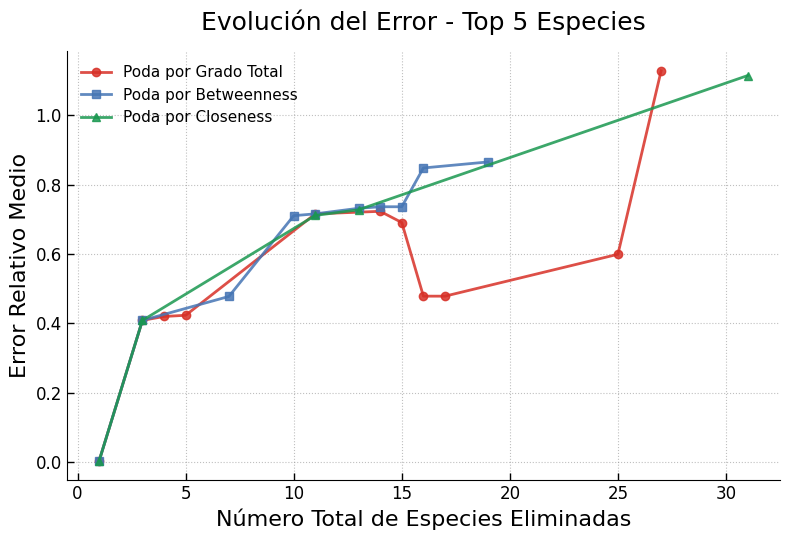

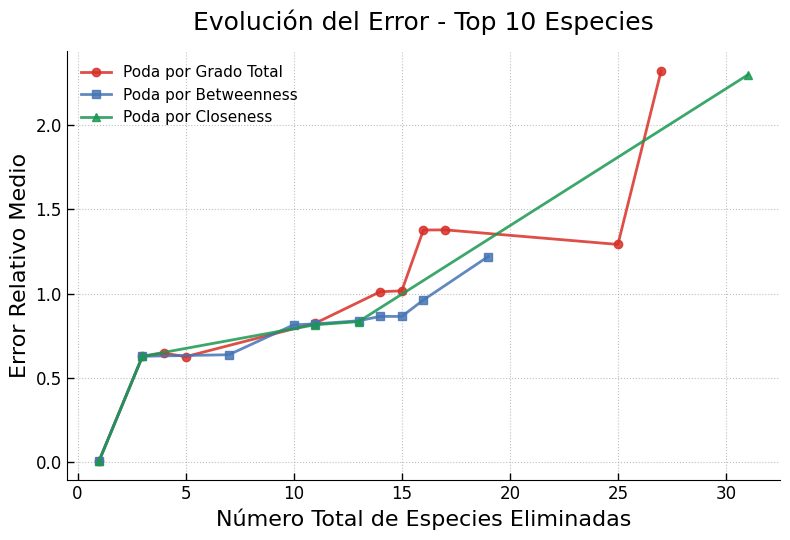

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================
# ⚠️ [PEGA AQUÍ TU FUNCIÓN: leer_densidades_loki()] ⚠️

# =============================================================================
# 1. CARGA DE TOPOLOGÍA Y SELECCIÓN DEL TOP 5 Y TOP 10
# =============================================================================
print("⚙️ Analizando topología para seleccionar las especies Target...")

nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_topo = pd.DataFrame({'nodo': nombres_nodos, 'grado': grado_total, 'betw': centralidad_b, 'close': centralidad_c})
df_topo['es_ion'] = df_topo['nodo'].apply(lambda x: '+' in x or '-' in x)

def normalizar(columna):
    min_val, max_val = columna.min(), columna.max()
    if max_val == min_val: return columna * 0.0
    return (columna - min_val) / (max_val - min_val)

df_topo['puntuacion_total'] = normalizar(df_topo['grado']) + normalizar(df_topo['betw']) + normalizar(df_topo['close'])

obligatorios = ['e', 'He(1S1)']
df_iones = df_topo[df_topo['es_ion'] & (~df_topo['nodo'].isin(obligatorios))]
mejor_ion = df_iones.sort_values(by='puntuacion_total', ascending=False).iloc[0]['nodo']
obligatorios.append(mejor_ion)

df_resto = df_topo[~df_topo['nodo'].isin(obligatorios)].sort_values(by='puntuacion_total', ascending=False)

top_5_especies = obligatorios + df_resto['nodo'].tolist()[:2]
top_10_especies = obligatorios + df_resto['nodo'].tolist()[:7]

print(f"🌟 TOP 5: {top_5_especies}")
print(f"🌟 TOP 10: {top_10_especies}")

# =============================================================================
# 2. LECTURA DE CARPETAS Y CÁLCULO DE ERRORES
# =============================================================================
ruta_base_salidas = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Output'

ruta_baseline = os.path.join(ruta_base_salidas, 'helium0', 'chemFinalDensities.txt')
if not os.path.exists(ruta_baseline):
    print(f"🔴 ERROR: No se encuentra la baseline en {ruta_baseline}")
    import sys; sys.exit(1)

densidades_base = leer_densidades_loki(ruta_baseline)
total_especies_originales = len(densidades_base)

def calcular_error_target(dict_iter, dict_base, target_list):
    """Calcula el error relativo normalizado SOLO para las especies de la target_list"""
    vivos = [n for n in target_list if n in dict_iter and n in dict_base]
    if not vivos: return 0.0
    
    dens_total_base_target = sum([dict_base[n] for n in vivos])
    dens_total_iter_target = sum([dict_iter[n] for n in vivos])
    
    suma_errores = 0.0
    for n in vivos:
        fraccion_base = dict_base[n] / dens_total_base_target if dens_total_base_target > 0 else 0
        fraccion_iter = dict_iter[n] / dens_total_iter_target if dens_total_iter_target > 0 else 0
        
        if fraccion_base > 0:
            suma_errores += abs(fraccion_iter - fraccion_base) / fraccion_base
            
    return suma_errores / len(vivos)

metricas_reduccion = ['grado_total', 'centralidad_b', 'centralidad_c']
datos_grafica_top5 = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_grafica_top10 = {m: {'x': [], 'y': []} for m in metricas_reduccion}

print("\n📊 Extrayendo datos de las carpetas de LoKI...")

for metrica in metricas_reduccion:
    iteracion = 1
    while True:
        carpeta_iter = f"helium_{metrica}{iteracion}"
        ruta_archivo_iter = os.path.join(ruta_base_salidas, carpeta_iter, 'chemFinalDensities.txt')
        
        if not os.path.exists(ruta_archivo_iter):
            break
            
        densidades_iter = leer_densidades_loki(ruta_archivo_iter)
        borrados = total_especies_originales - len(densidades_iter)
        
        err_5 = calcular_error_target(densidades_iter, densidades_base, top_5_especies)
        err_10 = calcular_error_target(densidades_iter, densidades_base, top_10_especies)
        
        datos_grafica_top5[metrica]['x'].append(borrados)
        datos_grafica_top5[metrica]['y'].append(err_5)
        
        datos_grafica_top10[metrica]['x'].append(borrados)
        datos_grafica_top10[metrica]['y'].append(err_10)
            
        iteracion += 1

# =============================================================================
# 3. GENERACIÓN DE GRÁFICAS
# =============================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16  
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12 
plt.rcParams['legend.fontsize'] = 11

estilos = {
    'grado_total': {'color': '#d73027', 'label': 'Poda por Grado Total', 'marker': 'o', 'linestyle': '-'},
    'centralidad_b': {'color': '#4575b4', 'label': 'Poda por Betweenness', 'marker': 's', 'linestyle': '-'},
    'centralidad_c': {'color': '#1a9850', 'label': 'Poda por Closeness', 'marker': '^', 'linestyle': '-'}
}

def plot_target_error_paper(diccionario_datos, nombre_archivo, titulo_grafica):
    fig, ax = plt.subplots(figsize=(8, 5.5)) 
    
    for metrica, datos in diccionario_datos.items():
        if len(datos['x']) > 0:
            estilo = estilos.get(metrica, {})
            ax.plot(datos['x'], datos['y'], 
                    marker=estilo.get('marker', 'o'), 
                    linestyle=estilo.get('linestyle', '-'), 
                    color=estilo.get('color', 'black'), 
                    label=estilo.get('label', metrica), 
                    linewidth=2.0, 
                    markersize=6,
                    alpha=0.85)
            
    # Títulos con los tamaños requeridos
    ax.set_title(titulo_grafica, fontsize=18, pad=15)
    ax.set_xlabel('Número Total de Especies Eliminadas', fontsize=16)
    ax.set_ylabel('Error Relativo Medio', fontsize=16)
    
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=5, width=1)
    
    ax.legend(frameon=False, loc='best')
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=600, bbox_inches='tight')
    plt.show()

# Llamadas con sus respectivos títulos
plot_target_error_paper(datos_grafica_top5, '01_Error_Fraccion_TOP5.png', 'Evolución del Error - Top 5 Especies')
plot_target_error_paper(datos_grafica_top10, '02_Error_Fraccion_TOP10.png', 'Evolución del Error - Top 10 Especies')


⚙️ Analizando topología y preparando pesos...
⚙️ Preparando Top 5 manual...
🔍 TOP 5 FORZADO a analizar acumulativamente: ['e', 'He(1S1)', 'He2(+,2S3)', 'He(2S1)', 'He(2S3)']

📊 Extrayendo datos de las carpetas de LoKI...


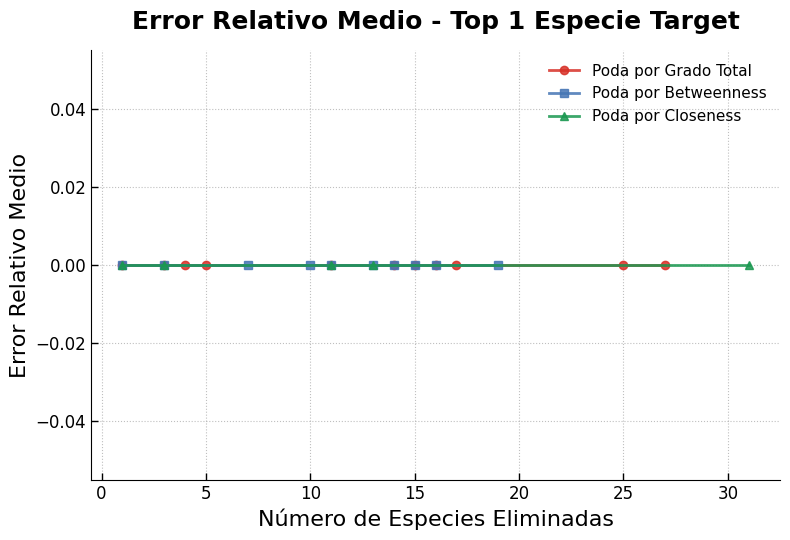

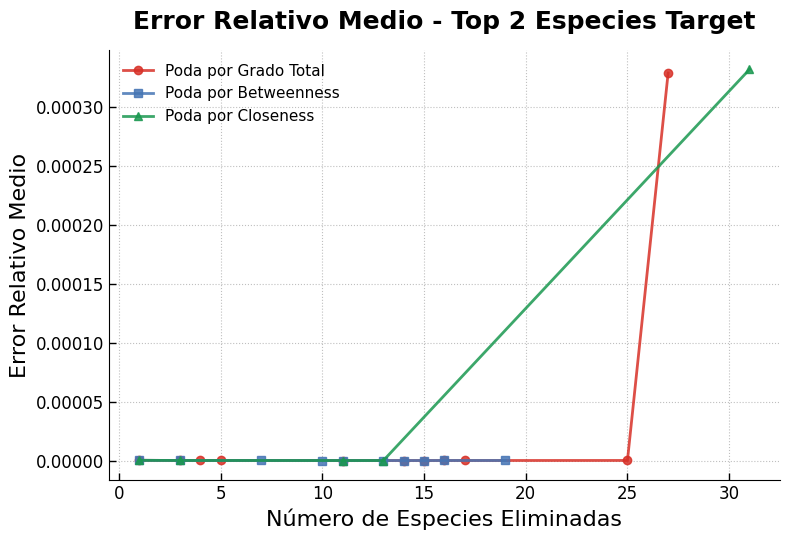

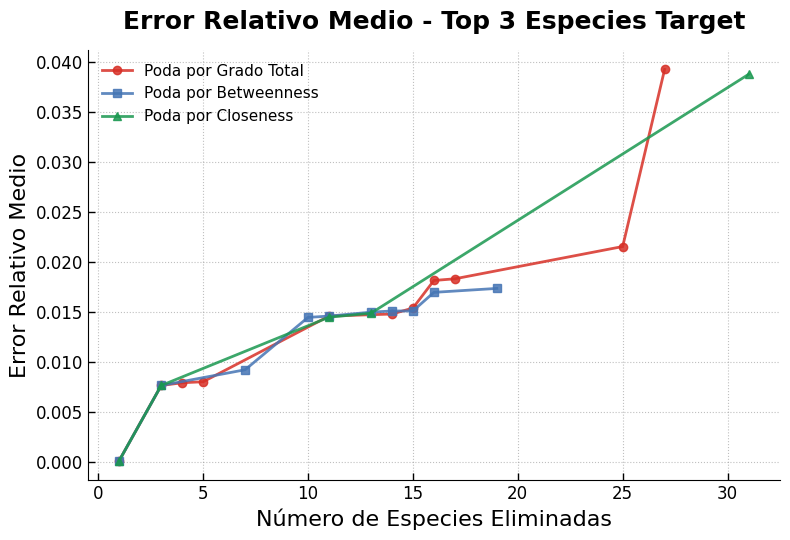

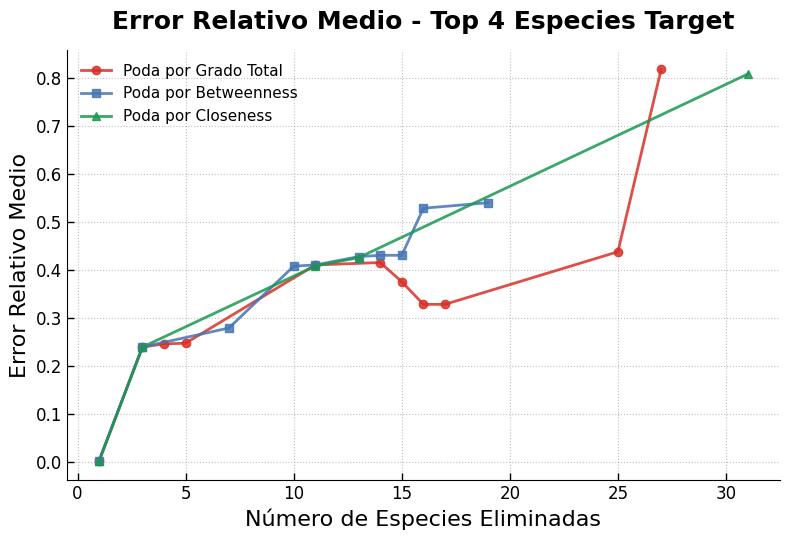

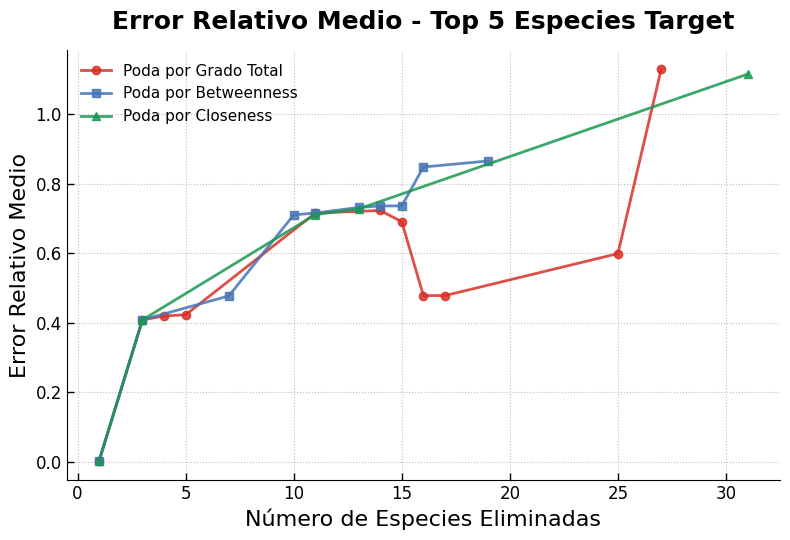


✅ Las 5 gráficas de ablación con Media Aritmética Simple han sido generadas correctamente.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================
def leer_densidades_loki(ruta_archivo):
    """
    Lee el archivo chemFinalDensities.txt y extrae {Especie: Densidad_Absoluta}.
    Ignora cabeceras, líneas separadoras y nombres de bloques.
    """
    densidades = {}
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            for linea in f:
                linea = linea.strip()
                if not linea or linea.startswith('*') or linea.startswith('-') or linea.startswith('Species'):
                    continue
                
                partes = linea.split()
                if len(partes) >= 4 and not partes[0].endswith(']'):
                    especie = partes[0]
                    try:
                        densidades[especie] = float(partes[1])
                    except ValueError:
                        continue
    except Exception as e:
        print(f"⚠️ Error leyendo {ruta_archivo}: {e}")
        
    return densidades

# =============================================================================
# 1. CARGA DE DATOS Y PREPARACIÓN DE PESOS (Solo para selección)
# =============================================================================
print("⚙️ Analizando topología y preparando pesos...")

nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_topo = pd.DataFrame({'nodo': nombres_nodos, 'grado': grado_total, 'betw': centralidad_b, 'close': centralidad_c})
df_topo['es_ion'] = df_topo['nodo'].apply(lambda x: '+' in x or '-' in x)

def normalizar(columna):
    min_val, max_val = columna.min(), columna.max()
    if max_val == min_val: return columna * 0.0
    return (columna - min_val) / (max_val - min_val)

df_topo['peso_total'] = normalizar(df_topo['grado']) + normalizar(df_topo['betw']) + normalizar(df_topo['close'])

# =============================================================================
# 2. SELECCIÓN MANUAL DEL TOP 5 (Forzando el He(2S1))
# =============================================================================
print("⚙️ Preparando Top 5 manual...")

obligatorios = ['e', 'He(1S1)']
df_iones = df_topo[df_topo['es_ion'] & (~df_topo['nodo'].isin(obligatorios))]
mejor_ion = df_iones.sort_values(by='peso_total', ascending=False).iloc[0]['nodo']
obligatorios.append(mejor_ion)

# Encontramos la especie que el algoritmo habría puesto en la 5ª posición (el 2º neutral libre)
df_resto = df_topo[~df_topo['nodo'].isin(obligatorios)].sort_values(by='peso_total', ascending=False)
mejor_neutral_restante = df_resto[df_resto['nodo'] != 'He(2S1)'].iloc[0]['nodo'] 

# Construimos la lista forzada
top_5_especies = obligatorios + ['He(2S1)', mejor_neutral_restante]

print(f"🔍 TOP 5 FORZADO a analizar acumulativamente: {top_5_especies}")

# =============================================================================
# 3. FUNCIÓN DE ERROR MEDIO (SIN PONDERAR)
# =============================================================================
def calcular_error_no_ponderado(dict_iter, dict_base, target_list):
    """
    Calcula la media aritmética del error relativo de las especies en la lista.
    Todas las especies seleccionadas tienen exactamente el mismo peso (1.0).
    """
    vivos = [n for n in target_list if n in dict_iter and n in dict_base]
    if not vivos: return 0.0
    
    suma_errores = 0.0
    
    for n in vivos:
        rho_base = dict_base[n]
        rho_iter = dict_iter[n]
        
        if rho_base > 0:
            # Error relativo absoluto de la densidad para esta especie
            error_n = abs(rho_iter - rho_base) / rho_base
            suma_errores += error_n
            
    # Devolvemos la media simple
    return suma_errores / len(vivos)

# =============================================================================
# 4. LECTURA DE CARPETAS Y CÁLCULO ACUMULATIVO
# =============================================================================
ruta_base_salidas = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Output'

# Leer Baseline
ruta_baseline = os.path.join(ruta_base_salidas, 'helium0', 'chemFinalDensities.txt')
if not os.path.exists(ruta_baseline):
    print(f"🔴 ERROR: No se encuentra la baseline en {ruta_baseline}")
    import sys; sys.exit(1)

densidades_base = leer_densidades_loki(ruta_baseline)
total_especies_originales = len(densidades_base)

metricas_ejecutadas = ['grado_total', 'centralidad_b', 'centralidad_c']
# Guardaremos los datos así: datos_graficas[metrica][n_especies_incluidas] = {'x': [], 'y': []}
datos_graficas = {m: {i: {'x': [], 'y': []} for i in range(1, 6)} for m in metricas_ejecutadas}

print("\n📊 Extrayendo datos de las carpetas de LoKI...")

for metrica in metricas_ejecutadas:
    iteracion = 1
    while True:
        carpeta_iter = f"helium_{metrica}{iteracion}"
        ruta_archivo_iter = os.path.join(ruta_base_salidas, carpeta_iter, 'chemFinalDensities.txt')
        
        if not os.path.exists(ruta_archivo_iter):
            break
            
        densidades_iter = leer_densidades_loki(ruta_archivo_iter)
        borrados = total_especies_originales - len(densidades_iter)
        
        # EL BUCLE ACUMULATIVO: Evaluamos desde 1 hasta 5 especies
        for i in range(1, 6):
            subconjunto_target = top_5_especies[:i]
            # Usamos la nueva función sin ponderación
            error_calculado = calcular_error_no_ponderado(densidades_iter, densidades_base, subconjunto_target)
            
            datos_graficas[metrica][i]['x'].append(borrados)
            datos_graficas[metrica][i]['y'].append(error_calculado)
            
        iteracion += 1

# =============================================================================
# 5. GENERACIÓN DE GRÁFICAS (CALIDAD PAPER)
# =============================================================================
# Configuración global estética (Consistencia visual con el resto del TFG)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['axes.labelsize'] = 16  
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12 
plt.rcParams['legend.fontsize'] = 11

estilos_metricas = {
    'grado_total': {'color': '#d73027', 'label': 'Poda por Grado Total', 'marker': 'o', 'linestyle': '-'},
    'centralidad_b': {'color': '#4575b4', 'label': 'Poda por Betweenness', 'marker': 's', 'linestyle': '-'},
    'centralidad_c': {'color': '#1a9850', 'label': 'Poda por Closeness', 'marker': '^', 'linestyle': '-'}
}

# Generamos 5 gráficas, una para cada nivel de inclusión de nodos
for i in range(1, 6):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    
    nodos_implicados = top_5_especies[:i]
    
    for metrica in metricas_ejecutadas:
        if len(datos_graficas[metrica][i]['x']) > 0:
            estilo = estilos_metricas.get(metrica, {})
            ax.plot(datos_graficas[metrica][i]['x'], datos_graficas[metrica][i]['y'], 
                    marker=estilo.get('marker', 'o'), 
                    linestyle=estilo.get('linestyle', '-'), 
                    color=estilo.get('color', 'black'), 
                    label=estilo.get('label', metrica), 
                    linewidth=2.0, 
                    markersize=6,
                    alpha=0.85)
                    
    titulo = f"Error Relativo Medio - Top {i} Especie{'s' if i > 1 else ''} Target"
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=15)

    ax.set_xlabel('Número de Especies Eliminadas', fontsize=16)
    ax.set_ylabel('Error Relativo Medio', fontsize=16)
    
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=5, width=1)
    
    ax.legend(frameon=False, loc='best')
    
    plt.tight_layout()
    
    # Exportamos con nombre identificativo
    nombre_archivo = f'Paper_Comparativa_Ablacion_{i}_Nodos_NoPond.png'
    plt.savefig(nombre_archivo, dpi=600, bbox_inches='tight')
    plt.show()  # <--- ESTO FUERZA A QUE SE MUESTREN EN TU PANTALLA

print("\n✅ Las 5 gráficas de ablación con Media Aritmética Simple han sido generadas correctamente.")
    

⚙️ Analizando topología y definiendo grupos de control...
🌟 TOP 5 Activo: ['e', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)', 'He(+,1S2)']
🌟 TOP 10 Activo: ['e', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)', 'He(+,1S2)', 'He(2P3)', 'He(2P1)', 'He(6D1)', 'He(4D1)', 'He(5D3)']

📊 Aplicando Ecuación de Error Ponderado por Densidad Actual...


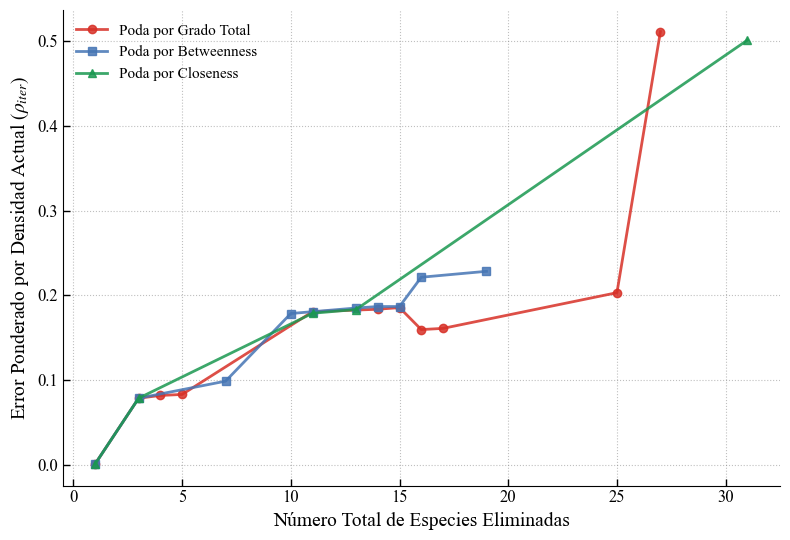

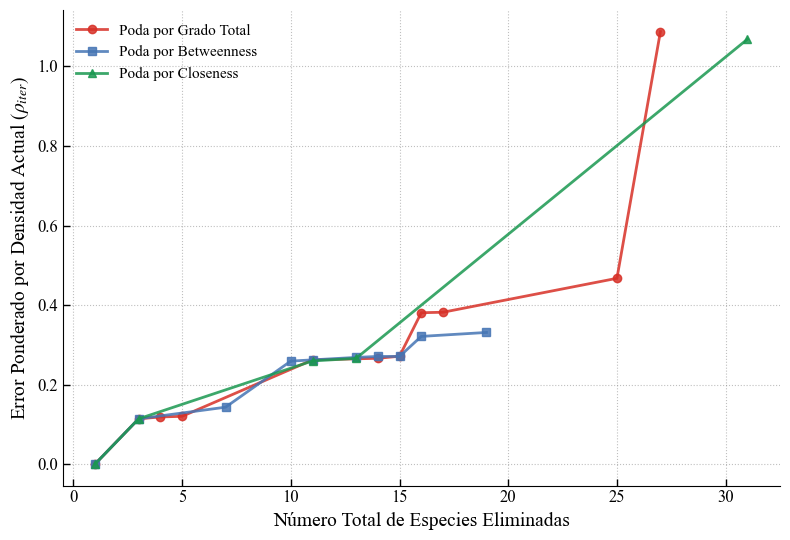

✅ Gráficas de error ponderado por densidad de iteración (rho_iter) generadas y listas para el TFG.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =============================================================================
# 1. FUNCIÓN ROBUSTA DE LECTURA DE LOKI
# =============================================================================
def leer_densidades_loki(ruta_archivo):
    """
    Lee el archivo chemFinalDensities.txt y extrae {Especie: Densidad_Absoluta}.
    Ignora cabeceras, líneas separadoras y nombres de bloques.
    """
    densidades = {}
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            for linea in f:
                linea = linea.strip()
                if not linea or linea.startswith('*') or linea.startswith('-') or linea.startswith('Species'):
                    continue
                
                partes = linea.split()
                if len(partes) >= 4 and not partes[0].endswith(']'):
                    especie = partes[0]
                    try:
                        densidades[especie] = float(partes[1])
                    except ValueError:
                        continue
    except Exception as e:
        print(f"⚠️ Error leyendo {ruta_archivo}: {e}")
        
    return densidades

# =============================================================================
# 2. CARGA DE TOPOLOGÍA Y SELECCIÓN DE VIPS
# =============================================================================
print("⚙️ Analizando topología y definiendo grupos de control...")

nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_topo = pd.DataFrame({'nodo': nombres_nodos, 'grado': grado_total, 'betw': centralidad_b, 'close': centralidad_c})
df_topo['es_ion'] = df_topo['nodo'].apply(lambda x: '+' in x or '-' in x)

def normalizar(columna):
    min_val, max_val = columna.min(), columna.max()
    if max_val == min_val: return columna * 0.0
    return (columna - min_val) / (max_val - min_val)

df_topo['peso_topologico'] = normalizar(df_topo['grado']) + normalizar(df_topo['betw']) + normalizar(df_topo['close'])

# SELECCIÓN DEL TOP 5 Y 10 (SIN GAS DE FONDO)
df_activos = df_topo[df_topo['nodo'] != 'He(1S1)'] 

obligatorios = ['e']
mejor_ion = df_activos[df_activos['es_ion'] & (df_activos['nodo'] != 'e')].sort_values(by='peso_topologico', ascending=False).iloc[0]['nodo']
obligatorios.append(mejor_ion)

df_resto = df_activos[~df_activos['nodo'].isin(obligatorios)].sort_values(by='peso_topologico', ascending=False)

top_5_especies = obligatorios + df_resto['nodo'].tolist()[:3]
top_10_especies = obligatorios + df_resto['nodo'].tolist()[:8]

print(f"🌟 TOP 5 Activo: {top_5_especies}")
print(f"🌟 TOP 10 Activo: {top_10_especies}")

# =============================================================================
# 3. LECTURA DE CARPETAS Y CÁLCULO DE ERROR PESADO POR DENSIDAD ACTUAL
# =============================================================================
ruta_base_salidas = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Output'

ruta_baseline = os.path.join(ruta_base_salidas, 'helium0', 'chemFinalDensities.txt')
if not os.path.exists(ruta_baseline):
    print(f"🔴 ERROR: No se encuentra la baseline en {ruta_baseline}")
    import sys; sys.exit(1)

densidades_base = leer_densidades_loki(ruta_baseline)
total_especies_originales = len(densidades_base)

def calcular_error_densidad_actual(dict_iter, dict_base, target_list):
    """
    Calcula el Error Relativo pesado por la DENSIDAD ACTUAL en cada iteración.
    Si una especie absorbe materia erróneamente en esa iteración, su peso se dispara.
    """
    vivos = [n for n in target_list if n in dict_iter and n in dict_base]
    if not vivos: return 0.0
    
    suma_error_por_densidad = 0.0
    suma_densidades_actuales = 0.0
    
    for n in vivos:
        rho_base = dict_base[n]
        rho_iter = dict_iter[n]
        
        if rho_base > 0:
            error_n = abs(rho_iter - rho_base) / rho_base
            
            # EL PESO ES LA DENSIDAD EN LA ITERACIÓN ACTUAL (rho_iter)
            peso_actual = rho_iter
            
            suma_error_por_densidad += (error_n * peso_actual)
            suma_densidades_actuales += peso_actual
            
    return (suma_error_por_densidad / suma_densidades_actuales) if suma_densidades_actuales > 0 else 0.0

metricas_reduccion = ['grado_total', 'centralidad_b', 'centralidad_c']
datos_grafica_top5 = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_grafica_top10 = {m: {'x': [], 'y': []} for m in metricas_reduccion}

print("\n📊 Aplicando Ecuación de Error Ponderado por Densidad Actual...")

for metrica in metricas_reduccion:
    iteracion = 1
    while True:
        carpeta_iter = f"helium_{metrica}{iteracion}"
        ruta_archivo_iter = os.path.join(ruta_base_salidas, carpeta_iter, 'chemFinalDensities.txt')
        
        if not os.path.exists(ruta_archivo_iter):
            break
            
        densidades_iter = leer_densidades_loki(ruta_archivo_iter)
        borrados = total_especies_originales - len(densidades_iter)
        
        err_5 = calcular_error_densidad_actual(densidades_iter, densidades_base, top_5_especies)
        err_10 = calcular_error_densidad_actual(densidades_iter, densidades_base, top_10_especies)
        
        datos_grafica_top5[metrica]['x'].append(borrados)
        datos_grafica_top5[metrica]['y'].append(err_5)
        
        datos_grafica_top10[metrica]['x'].append(borrados)
        datos_grafica_top10[metrica]['y'].append(err_10)
            
        iteracion += 1

# =============================================================================
# 4. GENERACIÓN DE GRÁFICAS (CALIDAD PAPER)
# =============================================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['axes.labelsize'] = 14  
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12 
plt.rcParams['legend.fontsize'] = 11

estilos = {
    'grado_total': {'color': '#d73027', 'label': 'Poda por Grado Total', 'marker': 'o', 'linestyle': '-'},
    'centralidad_b': {'color': '#4575b4', 'label': 'Poda por Betweenness', 'marker': 's', 'linestyle': '-'},
    'centralidad_c': {'color': '#1a9850', 'label': 'Poda por Closeness', 'marker': '^', 'linestyle': '-'}
}

def plot_error_densidad_actual_paper(diccionario_datos, nombre_archivo):
    fig, ax = plt.subplots(figsize=(8, 5.5)) 
    
    for metrica, datos in diccionario_datos.items():
        if len(datos['x']) > 0:
            estilo = estilos.get(metrica, {})
            ax.plot(datos['x'], datos['y'], 
                    marker=estilo.get('marker', 'o'), 
                    linestyle=estilo.get('linestyle', '-'), 
                    color=estilo.get('color', 'black'), 
                    label=estilo.get('label', metrica), 
                    linewidth=2.0, 
                    markersize=6,
                    alpha=0.85)
            
    ax.set_xlabel('Número Total de Especies Eliminadas', fontsize=14)
    # Etiqueta rigurosa especificando el tipo de peso actual
    ax.set_ylabel(r'Error Ponderado por Densidad Actual ($\rho_{iter}$)', fontsize=14)
    
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=5, width=1)
    
    ax.legend(frameon=False, loc='best')
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=600, bbox_inches='tight')
    plt.show()

plot_error_densidad_actual_paper(datos_grafica_top5, '01_Error_Densidad_Actual_TOP5_Paper.png')
plot_error_densidad_actual_paper(datos_grafica_top10, '02_Error_Densidad_Actual_TOP10_Paper.png')

print("✅ Gráficas de error ponderado por densidad de iteración (rho_iter) generadas y listas para el TFG.")

⚙️ Analizando topología y extrayendo el Peso Topológico de Consenso (W_i)...
🌟 TOP 5 Activo a vigilar: ['e', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)', 'He(+,1S2)']
🌟 TOP 10 Activo a vigilar: ['e', 'He2(+,2S3)', 'He(2S3)', 'He(2S1)', 'He(+,1S2)', 'He(2P3)', 'He(2P1)', 'He(6D1)', 'He(4D1)', 'He(5D3)']

📊 Aplicando Ecuación de Propagación de Error Topológico...


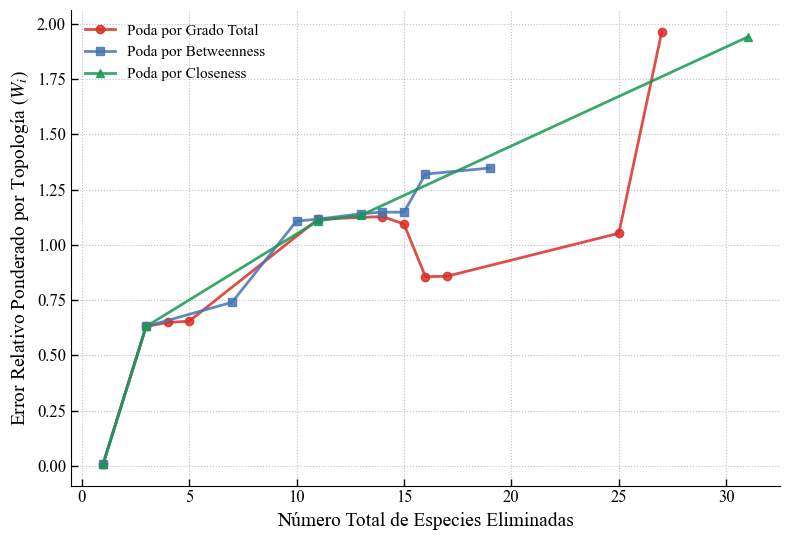

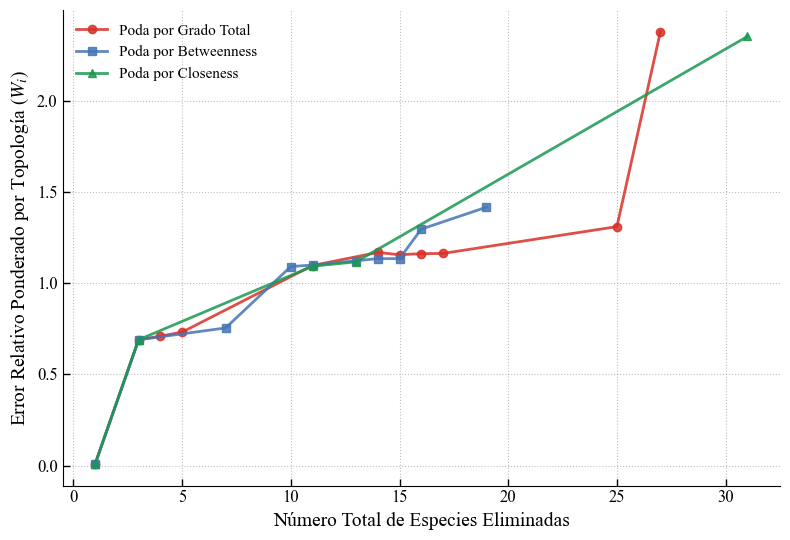

✅ Gráficas de error topológico finalizadas. Revisa los resultados; si la curva de Grado salta antes que Betweenness, tienes la demostración definitiva para tu TFG.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =============================================================================
# 1. FUNCIÓN ROBUSTA DE LECTURA DE LOKI
# =============================================================================
def leer_densidades_loki(ruta_archivo):
    """
    Lee el archivo chemFinalDensities.txt y extrae {Especie: Densidad_Absoluta}.
    Ignora cabeceras, líneas separadoras y nombres de bloques.
    """
    densidades = {}
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            for linea in f:
                linea = linea.strip()
                if not linea or linea.startswith('*') or linea.startswith('-') or linea.startswith('Species'):
                    continue
                
                partes = linea.split()
                if len(partes) >= 4 and not partes[0].endswith(']'):
                    especie = partes[0]
                    try:
                        densidades[especie] = float(partes[1])
                    except ValueError:
                        continue
    except Exception as e:
        print(f"⚠️ Error leyendo {ruta_archivo}: {e}")
        
    return densidades

# =============================================================================
# 2. CARGA DE TOPOLOGÍA Y CÁLCULO DE PESOS TOPOLÓGICOS
# =============================================================================
print("⚙️ Analizando topología y extrayendo el Peso Topológico de Consenso (W_i)...")

nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_topo = pd.DataFrame({'nodo': nombres_nodos, 'grado': grado_total, 'betw': centralidad_b, 'close': centralidad_c})
df_topo['es_ion'] = df_topo['nodo'].apply(lambda x: '+' in x or '-' in x)

def normalizar(columna):
    min_val, max_val = columna.min(), columna.max()
    if max_val == min_val: return columna * 0.0
    return (columna - min_val) / (max_val - min_val)

# El PESO TOPOLÓGICO DE CONSENSO (W_i)
df_topo['peso_topologico'] = normalizar(df_topo['grado']) + normalizar(df_topo['betw']) + normalizar(df_topo['close'])

# Diccionario rápido para asignar el peso a la fórmula matemática
diccionario_pesos_topo = dict(zip(df_topo['nodo'], df_topo['peso_topologico']))

# --- SELECCIÓN DEL TOP 5 Y 10 (SIN GAS DE FONDO) ---
df_activos = df_topo[df_topo['nodo'] != 'He(1S1)'] 

obligatorios = ['e']
mejor_ion = df_activos[df_activos['es_ion'] & (df_activos['nodo'] != 'e')].sort_values(by='peso_topologico', ascending=False).iloc[0]['nodo']
obligatorios.append(mejor_ion)

df_resto = df_activos[~df_activos['nodo'].isin(obligatorios)].sort_values(by='peso_topologico', ascending=False)

top_5_especies = obligatorios + df_resto['nodo'].tolist()[:3]
top_10_especies = obligatorios + df_resto['nodo'].tolist()[:8]

print(f"🌟 TOP 5 Activo a vigilar: {top_5_especies}")
print(f"🌟 TOP 10 Activo a vigilar: {top_10_especies}")

# =============================================================================
# 3. LECTURA DE CARPETAS Y CÁLCULO DE ERROR PONDERADO POR TOPOLOGÍA
# =============================================================================
ruta_base_salidas = r'C:\Users\Josea\OneDrive\Escritorio\Colaborador\Redes-Plasma\loki\loki\Code\Output'

ruta_baseline = os.path.join(ruta_base_salidas, 'helium0', 'chemFinalDensities.txt')
if not os.path.exists(ruta_baseline):
    print(f"🔴 ERROR: No se encuentra la baseline en {ruta_baseline}")
    import sys; sys.exit(1)

densidades_base = leer_densidades_loki(ruta_baseline)
total_especies_originales = len(densidades_base)

def calcular_error_pesado_por_topologia(dict_iter, dict_base, target_list, dict_pesos):
    """
    Calcula el Error Relativo pesado estrictamente por la IMPORTANCIA TOPOLÓGICA (W_i).
    Penaliza fuertemente los errores en los "puentes" y "hubs" de la red.
    """
    vivos = [n for n in target_list if n in dict_iter and n in dict_base]
    if not vivos: return 0.0
    
    suma_error_pond = 0.0
    suma_pesos = 0.0
    
    for n in vivos:
        rho_base = dict_base[n]
        rho_iter = dict_iter[n]
        
        if rho_base > 0:
            error_n = abs(rho_iter - rho_base) / rho_base
            
            # EL PESO ES LA CENTRALIDAD TOPOLÓGICA
            peso_n = dict_pesos.get(n, 1e-6) 
            
            suma_error_pond += (error_n * peso_n)
            suma_pesos += peso_n
            
    return (suma_error_pond / suma_pesos) if suma_pesos > 0 else 0.0

metricas_reduccion = ['grado_total', 'centralidad_b', 'centralidad_c']
datos_grafica_top5 = {m: {'x': [], 'y': []} for m in metricas_reduccion}
datos_grafica_top10 = {m: {'x': [], 'y': []} for m in metricas_reduccion}

print("\n📊 Aplicando Ecuación de Propagación de Error Topológico...")

for metrica in metricas_reduccion:
    iteracion = 1
    while True:
        carpeta_iter = f"helium_{metrica}{iteracion}"
        ruta_archivo_iter = os.path.join(ruta_base_salidas, carpeta_iter, 'chemFinalDensities.txt')
        
        if not os.path.exists(ruta_archivo_iter):
            break
            
        densidades_iter = leer_densidades_loki(ruta_archivo_iter)
        borrados = total_especies_originales - len(densidades_iter)
        
        err_5 = calcular_error_pesado_por_topologia(densidades_iter, densidades_base, top_5_especies, diccionario_pesos_topo)
        err_10 = calcular_error_pesado_por_topologia(densidades_iter, densidades_base, top_10_especies, diccionario_pesos_topo)
        
        datos_grafica_top5[metrica]['x'].append(borrados)
        datos_grafica_top5[metrica]['y'].append(err_5)
        
        datos_grafica_top10[metrica]['x'].append(borrados)
        datos_grafica_top10[metrica]['y'].append(err_10)
            
        iteracion += 1

# =============================================================================
# 4. GENERACIÓN DE GRÁFICAS FINALES (CALIDAD PAPER)
# =============================================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['axes.labelsize'] = 14  
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12 
plt.rcParams['legend.fontsize'] = 11

estilos = {
    'grado_total': {'color': '#d73027', 'label': 'Poda por Grado Total', 'marker': 'o', 'linestyle': '-'},
    'centralidad_b': {'color': '#4575b4', 'label': 'Poda por Betweenness', 'marker': 's', 'linestyle': '-'},
    'centralidad_c': {'color': '#1a9850', 'label': 'Poda por Closeness', 'marker': '^', 'linestyle': '-'}
}

def plot_error_topologia_paper(diccionario_datos, nombre_archivo):
    fig, ax = plt.subplots(figsize=(8, 5.5)) 
    
    for metrica, datos in diccionario_datos.items():
        if len(datos['x']) > 0:
            estilo = estilos.get(metrica, {})
            ax.plot(datos['x'], datos['y'], 
                    marker=estilo.get('marker', 'o'), 
                    linestyle=estilo.get('linestyle', '-'), 
                    color=estilo.get('color', 'black'), 
                    label=estilo.get('label', metrica), 
                    linewidth=2.0, 
                    markersize=6,
                    alpha=0.85)
            
    ax.set_xlabel('Número Total de Especies Eliminadas', fontsize=14)
    # Etiqueta rigurosa especificando el tipo de peso (W_i)
    ax.set_ylabel(r'Error Relativo Ponderado por Topología ($W_i$)', fontsize=14)
    
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=5, width=1)
    
    ax.legend(frameon=False, loc='best')
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=600, bbox_inches='tight')
    plt.show()

plot_error_topologia_paper(datos_grafica_top5, '01_Error_Topologico_TOP5_Paper.png')
plot_error_topologia_paper(datos_grafica_top10, '02_Error_Topologico_TOP10_Paper.png')

print("✅ Gráficas de error topológico finalizadas. Revisa los resultados; si la curva de Grado salta antes que Betweenness, tienes la demostración definitiva para tu TFG.")

In [4]:
import numpy as np
nombres_nodos = np.load('orden_nodos_helio.npy', allow_pickle=True)
grado_total = np.load('grado_total_helio.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_helio.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_helio.npy', allow_pickle=True)

df_nodos = preparar_red_optimizacion(nombres_nodos, grado_total, centralidad_c, centralidad_b)

df_resumen = mostrar_rankings_topologicos(df_nodos)
display(df_resumen)

,Top_Grado,Valor_Grado,|,Top_Closeness,Valor_Close,||,Top_Betweenness,Valor_Betw
Ranking,,,,,,,,
1,e,1502.0,|,e,1.000000,|,e,0.115329
2,He(1S1),526.0,|,He(1S1),1.000000,|,He(1S1),0.115329
3,He(2S3),213.0,|,"He2(+,2S3)",1.000000,|,He(2S3),0.107237
4,He(2S1),205.0,|,"He(+,1S2)",0.978723,|,He(2S1),0.096311
5,He(2P3),137.0,|,He(2S3),0.978723,|,He(2P3),0.029722
6,He(2P1),134.0,|,He(2S1),0.958333,|,He(2P1),0.024110
7,"He2(+,2S3)",119.0,|,He(2P3),0.696970,|,"He2(+,2S3)",0.006716
8,"He(+,1S2)",113.0,|,He(2P1),0.686567,|,He(6D1),0.004911
9,He(5D3),83.0,|,He(6D1),0.613333,|,He(5D1),0.003988


In [4]:
nombres_nodos = np.load('orden_nodos_oxigeno_vib.npy', allow_pickle=True)
grado_total = np.load('grado_total_oxigeno_vib.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_oxigeno.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_oxigeno.npy', allow_pickle=True)

df_nodos = preparar_red_optimizacion(nombres_nodos, grado_total, centralidad_c, centralidad_b)

df_resumen = mostrar_rankings_topologicos(df_nodos)
display(df_resumen)

,Top_Grado,Valor_Grado,|,Top_Closeness,Valor_Close,||,Top_Betweenness,Valor_Betw
Ranking,,,,,,,,
1,e,4000.0,|,"O2(X,v=0)",1.000000,|,"O2(X,v=0)",0.068374
2,O(3P),3639.5,|,O(3P),1.000000,|,O(3P),0.056429
3,O(1D),3294.0,|,e,0.915254,|,e,0.035213
4,"O2(X,v=29)",834.0,|,O(1D),0.900000,|,O2(X),0.021449
5,"O2(X,v=28)",834.0,|,O2(X),0.885246,|,O(1D),0.016641
6,"O2(X,v=27)",834.0,|,"O2(+,X)",0.870968,|,"O(-,gnd)",0.003564
7,"O2(X,v=30)",834.0,|,"O2(X,v=1)",0.870968,|,O2(a1Dg),0.002703
8,"O2(X,v=26)",834.0,|,"O2(X,v=8)",0.870968,|,"O2(X,v=5)",0.002184
9,"O2(X,v=25)",834.0,|,"O2(X,v=7)",0.870968,|,"O2(X,v=4)",0.002184


In [5]:
nombres_nodos = np.load('orden_nodos_n2h2.npy', allow_pickle=True)
grado_total = np.load('grado_total_n2h2.npy', allow_pickle=True)
centralidad_c = np.load('centralidad_c_n2h2.npy', allow_pickle=True)
centralidad_b = np.load('centralidad_b_n2h2.npy', allow_pickle=True)

df_nodos = preparar_red_optimizacion(nombres_nodos, grado_total, centralidad_c, centralidad_b)

df_resumen = mostrar_rankings_topologicos(df_nodos)
display(df_resumen)

,Top_Grado,Valor_Grado,|,Top_Closeness,Valor_Close,||,Top_Betweenness,Valor_Betw
Ranking,,,,,,,,
1,e,3634.0,|,H(1S),0.862903,|,H(1S),0.119002
2,N(4S),1832.0,|,"N2(X,v=0)",0.829457,|,"H2(X,v=0)",0.086368
3,H(1S),1777.0,|,e,0.810606,|,e,0.073624
4,N(2P),874.5,|,"H2(X,v=0)",0.804511,|,N(4S),0.059249
5,"N2(X,v=14)",818.0,|,"N2(X,v=3)",0.743056,|,"N2(X,v=0)",0.056029
...,...,...,...,...,...,...,...,...
104,wall_H(S),15.0,|,"N4(+,X)",0.465217,|,N2(C3Pu),0.000004
105,wall_NH(S),15.0,|,wall_N(S),0.434959,|,"NH2(-,X)",0.000000
106,wall_NH2(S),13.0,|,wall_N(F),0.433198,|,"N2(+,B2Su+)",0.000000
